# Diagnostic : pourquoi les coefficients de Kalman ne "convergent" pas ?

Ce notebook reproduit **exactement** la méthodologie du notebook de référence
([`kalman_sur1h.ipynb`](https://github.com/PierreRobinSchnepf/Applied-Statistics-ENGIE/blob/main/notebooks/archive/kalman_sur1h.ipynb))
sur notre jeu de données, pour isoler ce qui change par rapport à
`models.kalman.HourlyKalmanSURModel` (notre version "production") et vérifier
si l'absence de convergence observée est un bug ou un effet réel des données.

**3 écarts entre notre modèle production et le notebook de référence :**

| | Production (`HourlyKalmanSURModel`) | Référence GitHub |
|---|---|---|
| Intercept | **fixe** (`β_0` du SUR, pas de facteur Kalman dessus — conforme à la slide) | **dynamique**, glissé dans l'état Kalman lui-même (`state[0]`, initialisé à 1, PAS ancré sur `β_0` du SUR) |
| Bruit d'observation `V` | estimé automatiquement par heure (variance résiduelle du SUR en log, ~0.02 à l'heure 7) | constante fixe **0.1**, réglée pour une seule équation (heure 7) d'un autre jeu de données |
| Bruit de process `W` | scalaire uniforme **1e-4** sur les 25 états | vecteur **[1e-3, 5e-5, 5e-5, ...]** (composante intercept traitée à part) |
| Prédicteurs | Tableau 1 uniquement (26 variables) | Tableau 1 **+ `trend` + `quad_trend`** (indice de jour, absorbe une dérive de long terme) |

On reproduit les 3 réglages du tableau de droite à l'identique, avec et sans
`trend`/`quad_trend`, et on compare à la production — sur l'heure 7, comme
le fait le notebook de référence.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from models.dataset import load_dataset, build_hourly_equations, split_train_test, PREDICTOR_COLUMNS
from models.sure import HourlySUREModel
from models.kalman import HourlyKalmanSURModel, _run_kalman, LOG_TARGET_COLUMN, _with_log_target

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
HOUR = 7  # heure étudiée dans le notebook de référence

df = load_dataset()
per_hour = build_hourly_equations(df)
train, test = split_train_test(per_hour, test_start="2025-01-01", test_end="2026-01-01")

# Contexte : la cible n'est pas stationnaire sur 2018-2025 (baisse structurelle,
# en partie liée à la crise énergétique européenne de 2022) — aucune variable
# du Tableau 1 ne capture ça explicitement.
df["y_gas_mw"].resample("YS").mean().round(0)

build_hourly_equations: panel équilibré sur 3055 jours (jours exclus par heure pour déséquilibre : {0: 10, 1: 14, 2: 5, 3: 13, 4: 14, 5: 14, 6: 14, 7: 14, 8: 14, 9: 14, 10: 14, 11: 14, 12: 14, 13: 14, 14: 14, 15: 14, 16: 14, 17: 14, 18: 14, 19: 14, 20: 14, 21: 13, 22: 13, 23: 13})


2018-01-01 00:00:00+00:00    53690.0
2019-01-01 00:00:00+00:00    54672.0
2020-01-01 00:00:00+00:00    50578.0
2021-01-01 00:00:00+00:00    53871.0
2022-01-01 00:00:00+00:00    48395.0
2023-01-01 00:00:00+00:00    42624.0
2024-01-01 00:00:00+00:00    40133.0
2025-01-01 00:00:00+00:00    38899.0
2026-01-01 00:00:00+00:00    44768.0
Freq: YS-JAN, Name: y_gas_mw, dtype: float64

In [2]:
# Ajoute trend/quad_trend (indice de jour continu train->test), comme le notebook de référence
all_dates = sorted(set(train[0].index) | set(test[0].index))
trend_map = {d: i + 1 for i, d in enumerate(all_dates)}
for h in range(24):
    train[h] = train[h].copy()
    train[h]["trend"] = train[h].index.map(trend_map).astype(float)
    train[h]["quad_trend"] = train[h]["trend"] ** 2

PRED_NO_TREND = PREDICTOR_COLUMNS
PRED_WITH_TREND = PREDICTOR_COLUMNS + ["trend", "quad_trend"]

log_train = _with_log_target(train, "y_gas_mw")
sure_no_trend = HourlySUREModel(predictor_cols=PRED_NO_TREND).fit(log_train, target_col=LOG_TARGET_COLUMN)
sure_with_trend = HourlySUREModel(predictor_cols=PRED_WITH_TREND).fit(log_train, target_col=LOG_TARGET_COLUMN)

print("coef. SUR (log) trend / quad_trend, heure 7 :",
      round(sure_with_trend.coefficients().loc[HOUR, "trend"], 6),
      round(sure_with_trend.coefficients().loc[HOUR, "quad_trend"], 9))

coef. SUR (log) trend / quad_trend, heure 7 : 0.0001 -8.8e-08


In [3]:
def build_H_reference_style(sure_model, frame, predictor_cols, hour):
    """H = [1, x_1*beta_SUR_1, ..., x_p*beta_SUR_p] — intercept dynamique
    (colonne de 1, PAS beta_0*1), exactement comme sur_terms_matrix() dans
    le notebook de référence."""
    terms = [c for c in predictor_cols if c != "beta_0"]
    beta_sur = sure_model.coefficients().loc[hour, terms].to_numpy(dtype=float)
    X = frame[terms].to_numpy(dtype=float)
    H = np.column_stack([np.ones(len(frame)), X * beta_sur[None, :]])
    return H, ["const_dyn"] + terms

def run_reference_kalman(H, y):
    m = H.shape[1]
    V, W = 0.1, np.concatenate(([1e-3], np.repeat(5e-5, m - 1)))  # hyperparamètres EXACTS du notebook de référence
    beta_hist, _, _, _ = _run_kalman(H, y, V, W, m)
    return beta_hist

y_train_log = log_train[HOUR][LOG_TARGET_COLUMN].to_numpy()

H_no_trend, names_no_trend = build_H_reference_style(sure_no_trend, log_train[HOUR], PRED_NO_TREND, HOUR)
H_with_trend, names_with_trend = build_H_reference_style(sure_with_trend, log_train[HOUR], PRED_WITH_TREND, HOUR)

traj_faithful_no_trend = pd.DataFrame(run_reference_kalman(H_no_trend, y_train_log), columns=names_no_trend, index=log_train[HOUR].index)
traj_faithful_with_trend = pd.DataFrame(run_reference_kalman(H_with_trend, y_train_log), columns=names_with_trend, index=log_train[HOUR].index)

# Notre modèle production (intercept fixe, V/W "maison"), pour comparaison
prod_model = HourlyKalmanSURModel().fit(train)
traj_production = prod_model.train_beta_history_[HOUR]

## 1. Trajectoires du facteur d'ajustement sur `temp_smo` (heure 7, entraînement)

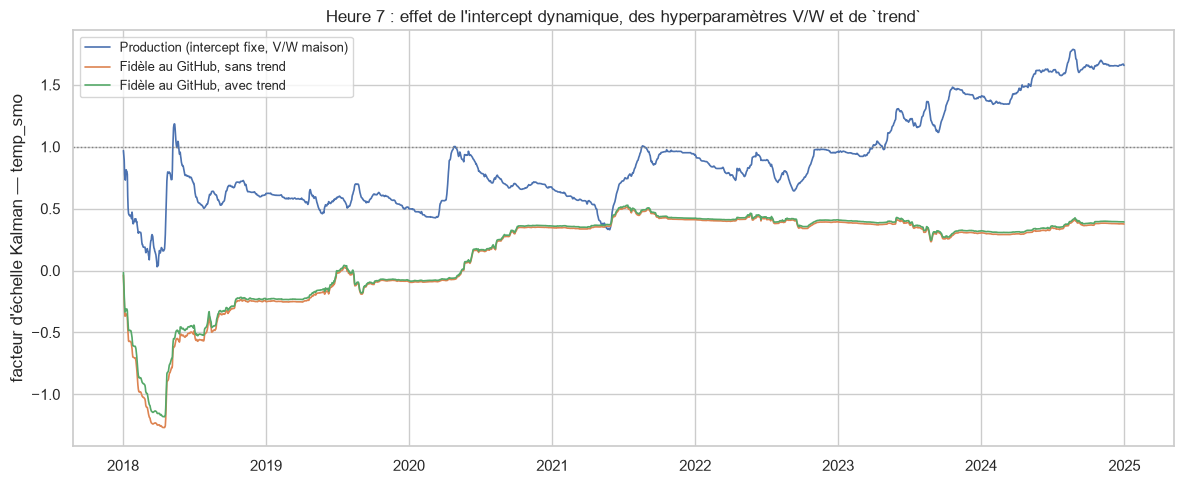

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(traj_production.index, traj_production["temp_smo"], label="Production (intercept fixe, V/W maison)", linewidth=1.2)
ax.plot(traj_faithful_no_trend.index, traj_faithful_no_trend["temp_smo"], label="Fidèle au GitHub, sans trend", linewidth=1.2)
ax.plot(traj_faithful_with_trend.index, traj_faithful_with_trend["temp_smo"], label="Fidèle au GitHub, avec trend", linewidth=1.2)
ax.axhline(1.0, color="grey", linestyle=":", linewidth=1)
ax.set_ylabel("facteur d'échelle Kalman — temp_smo")
ax.set_title("Heure 7 : effet de l'intercept dynamique, des hyperparamètres V/W et de `trend`")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 1bis. Évolution de *tous* les coefficients (pas seulement `temp_smo`)
Une grille par variante, un panneau par variable, sur toute la période d'entraînement.

In [5]:
def plot_all_trajectories(traj: pd.DataFrame, title: str, ncols: int = 4):
    cols = list(traj.columns)
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.3 * nrows), squeeze=False)
    axes = axes.ravel()

    for j, col in enumerate(cols):
        ax = axes[j]
        ax.plot(traj.index, traj[col].to_numpy(), lw=1.2, color="#4C72B0")
        ax.axhline(1.0, color="grey", linestyle=":", linewidth=1)
        ax.set_title(col, fontsize=9)
        ax.tick_params(axis="x", labelrotation=30, labelsize=7)

    for j in range(len(cols), len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

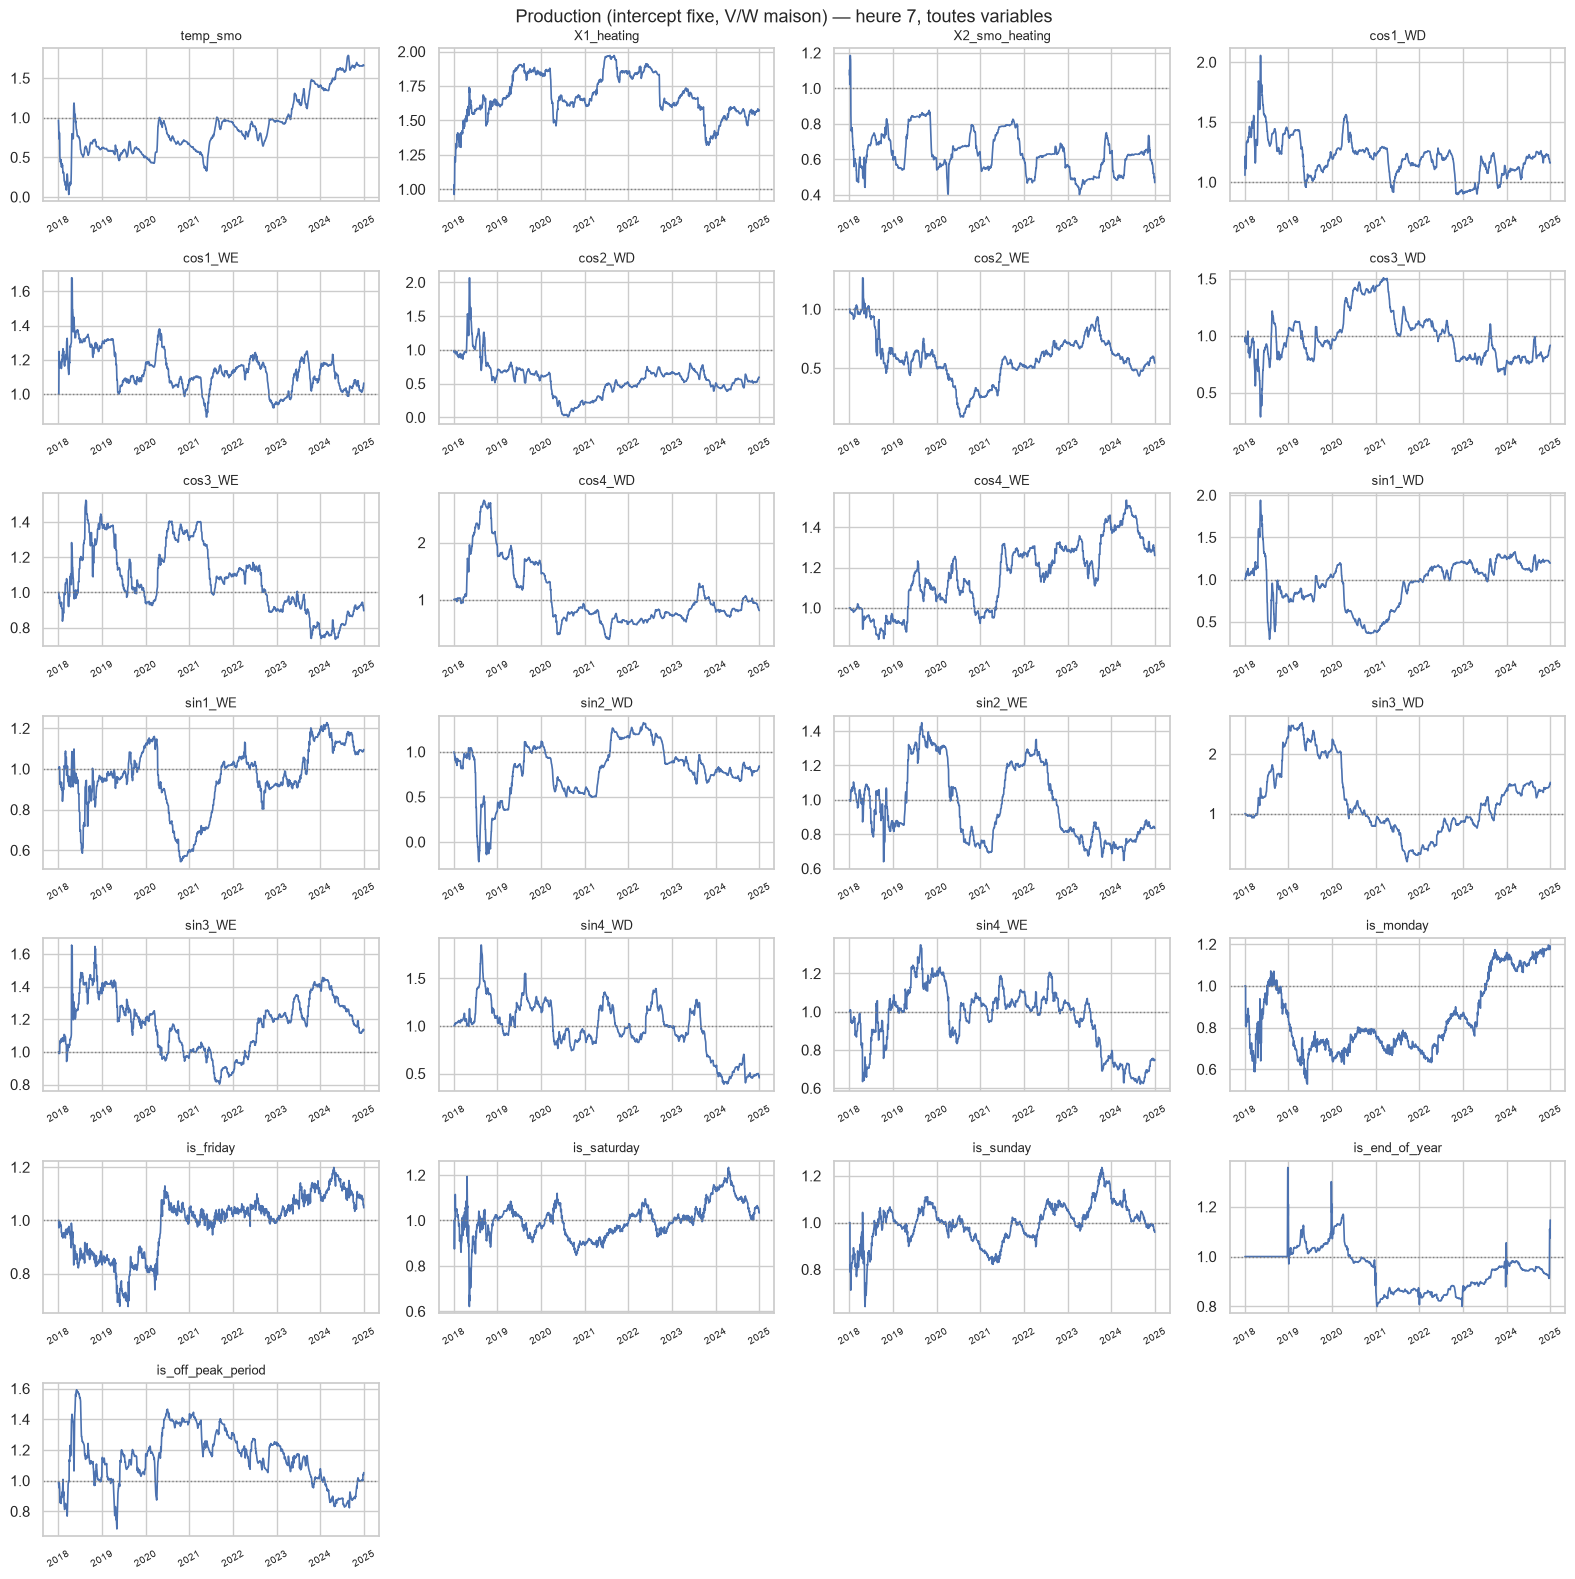

In [6]:
plot_all_trajectories(traj_production, "Production (intercept fixe, V/W maison) — heure 7, toutes variables")

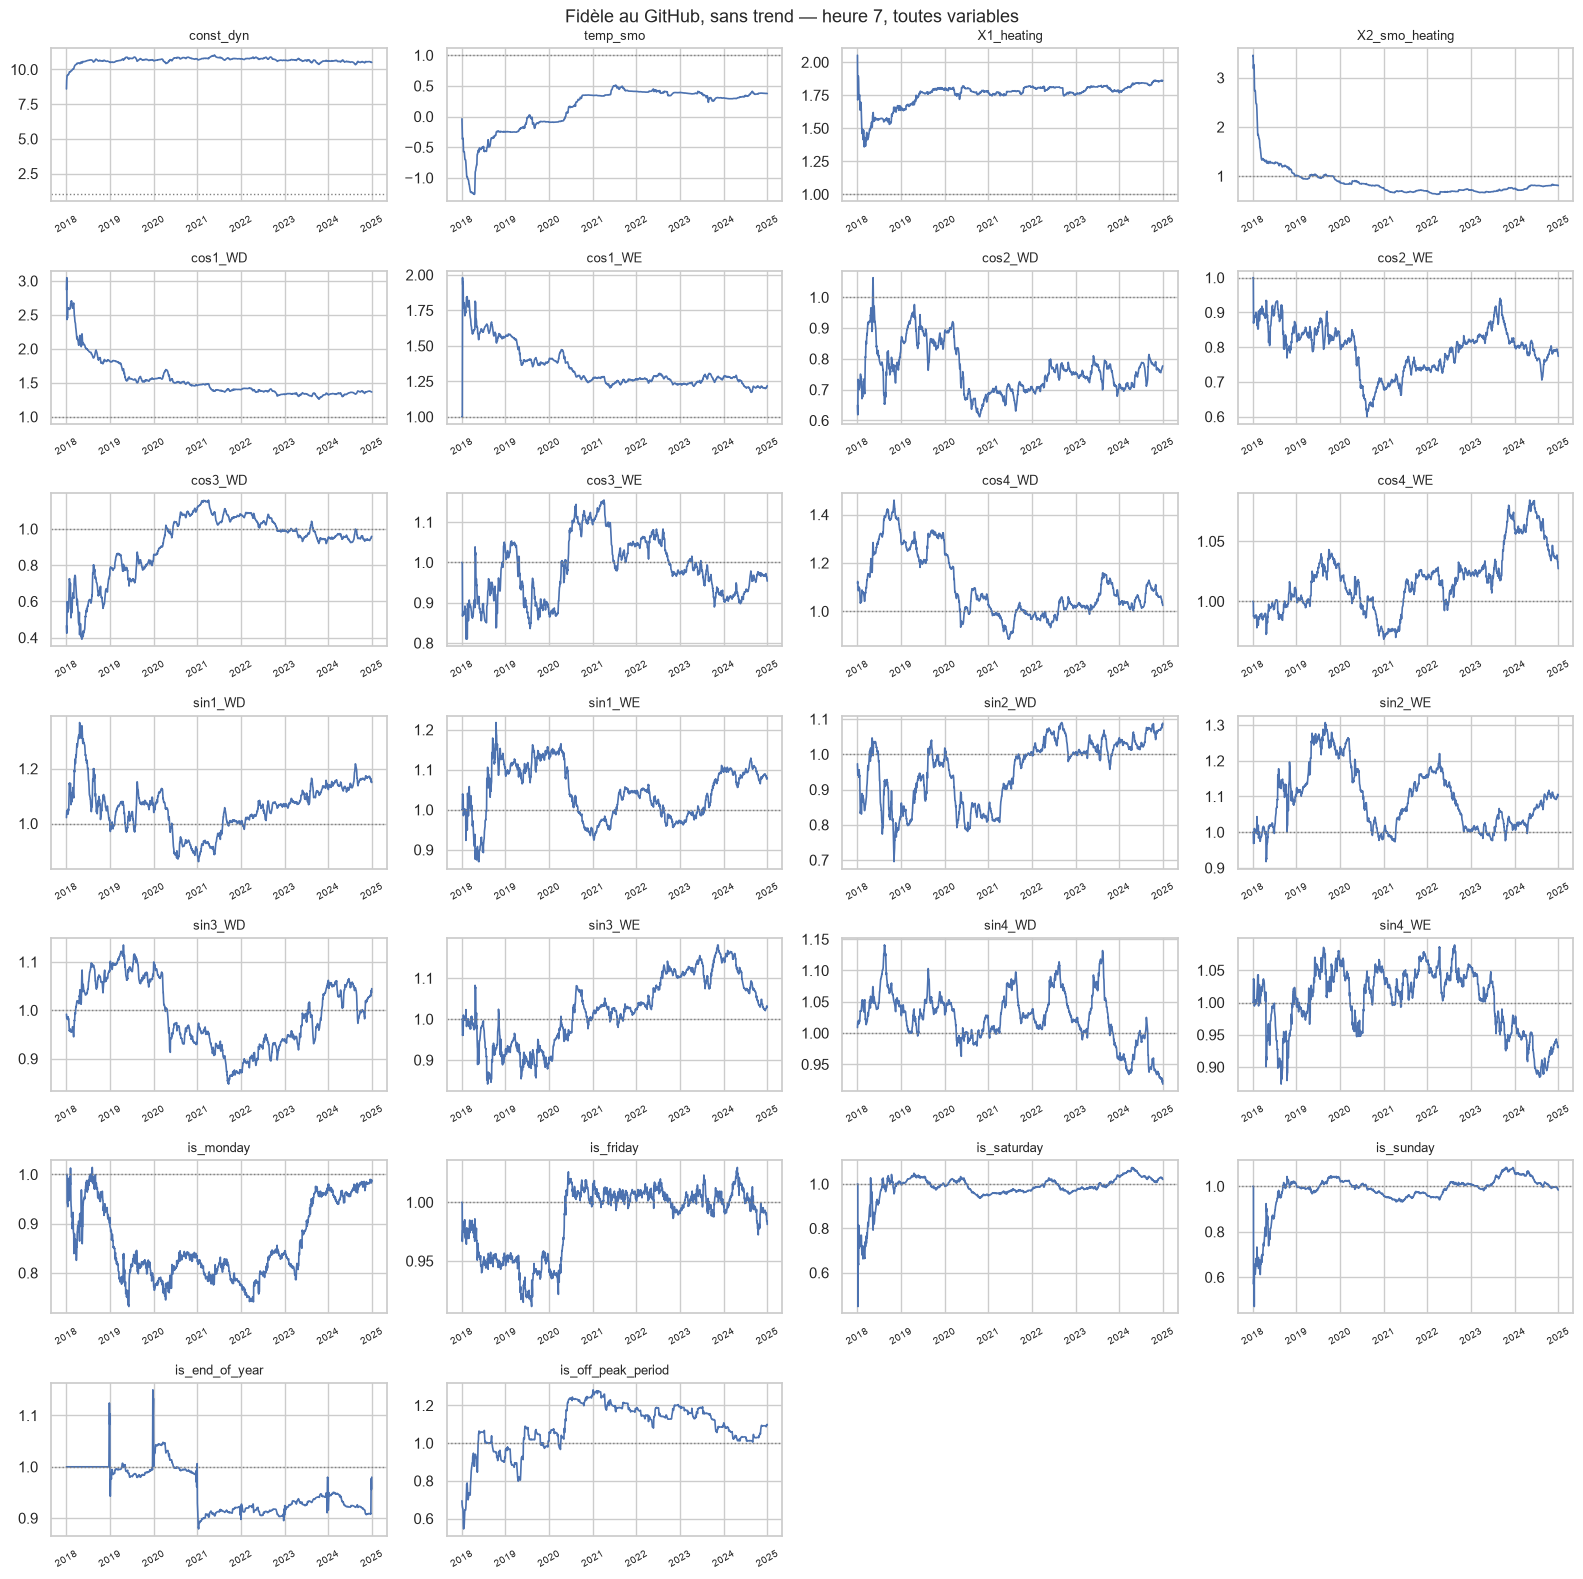

In [7]:
plot_all_trajectories(traj_faithful_no_trend, "Fidèle au GitHub, sans trend — heure 7, toutes variables")

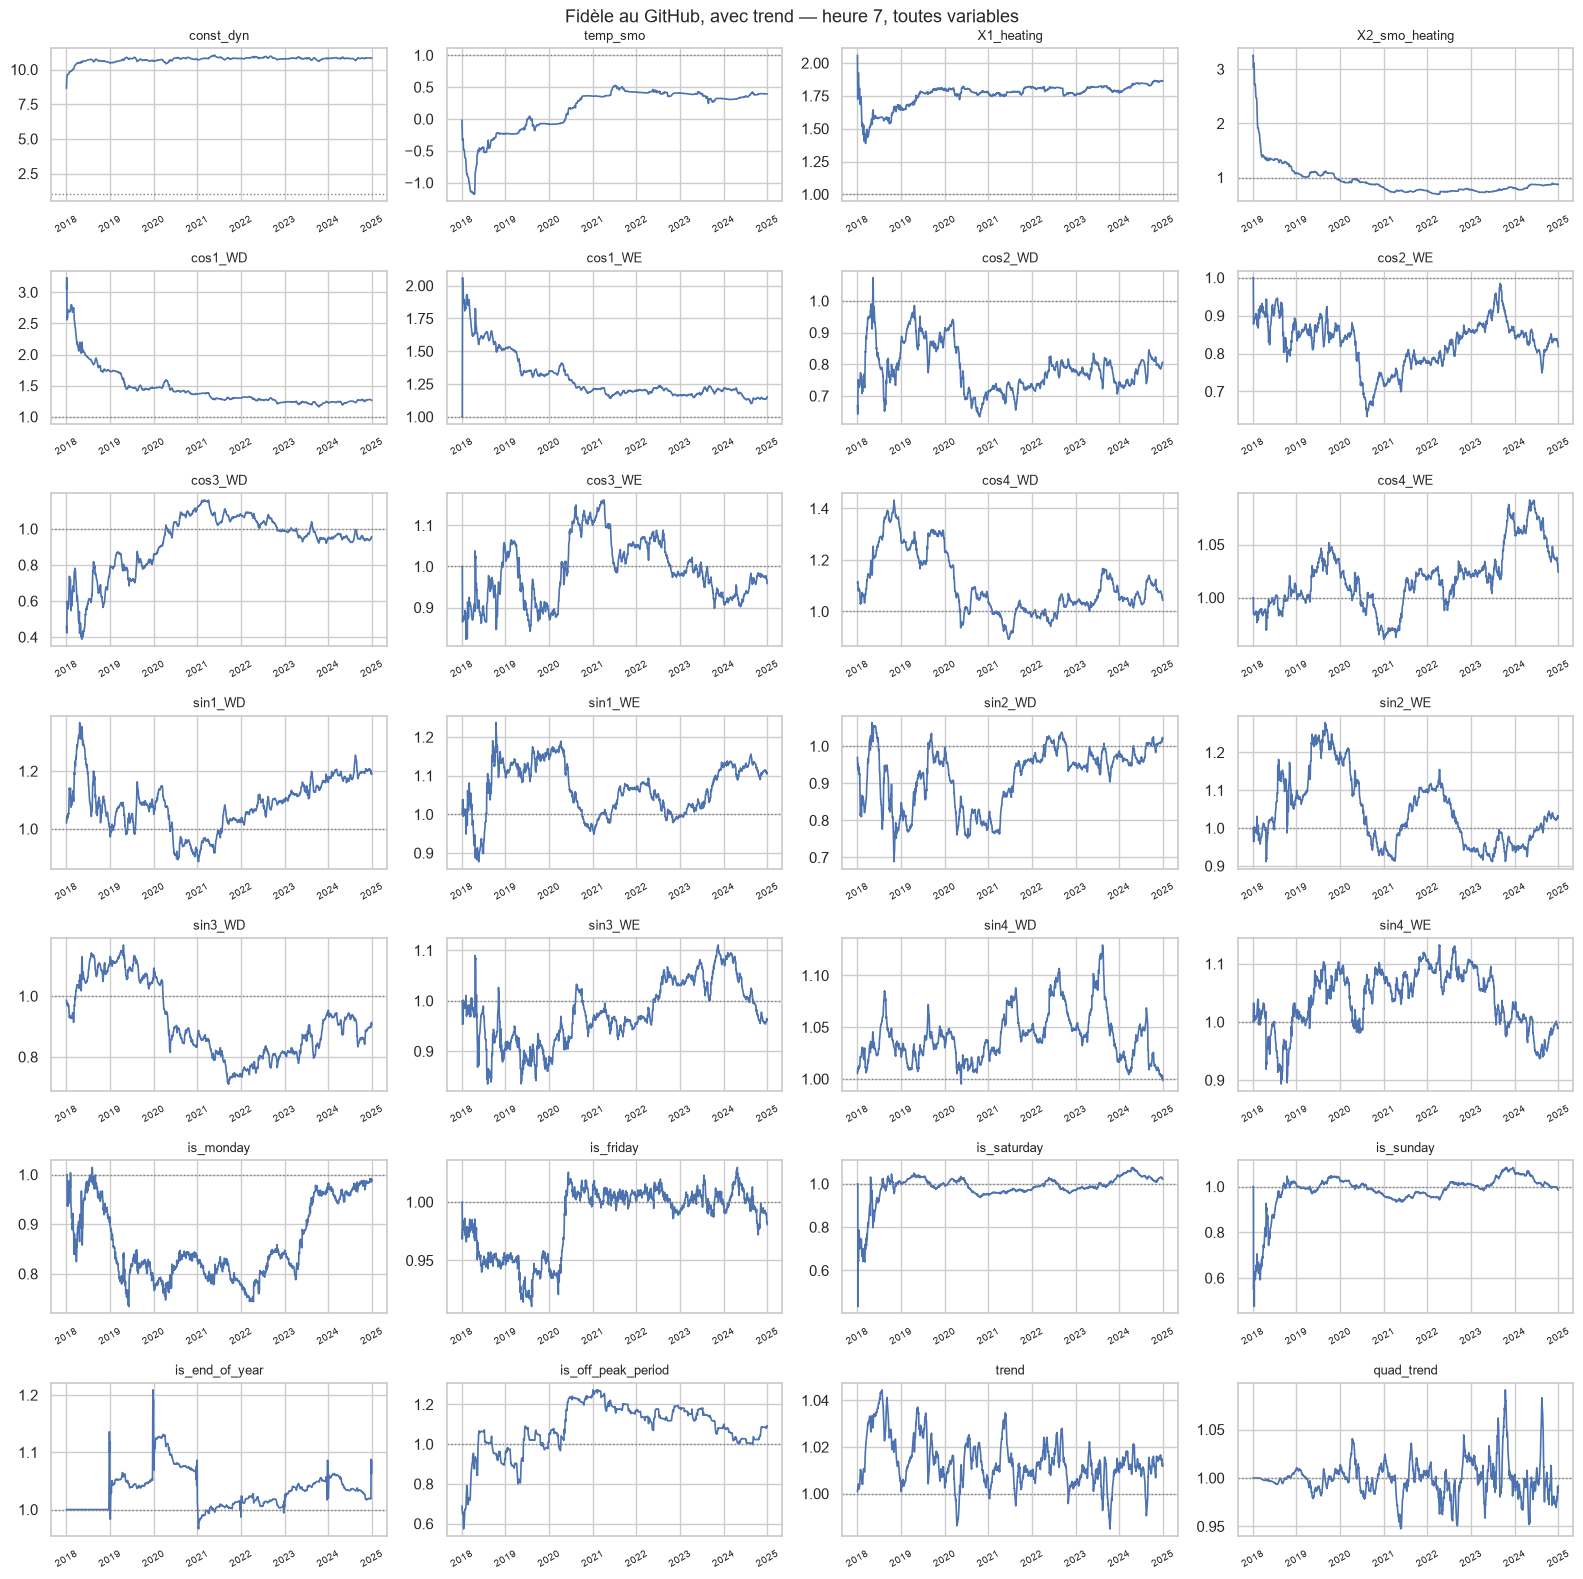

In [8]:
plot_all_trajectories(traj_faithful_with_trend, "Fidèle au GitHub, avec trend — heure 7, toutes variables")

## 2. Le gain converge bel et bien — mesuré par la volatilité jour-à-jour
Si le filtre "ne convergeait pas" au sens d'un gain instable, les variations jour-à-jour resteraient grandes jusqu'à la fin de l'entraînement. Ce n'est pas le cas dans aucune des 3 variantes : elles chutent toutes d'un ordre de grandeur entre le début et la fin du train.

In [9]:
def volatility_table(traj, col):
    d = traj[col].diff()
    return {"std 100 premiers jours": d.iloc[:100].std(), "std 100 derniers jours": d.iloc[-100:].std(),
            "plage totale (min-max)": traj[col].max() - traj[col].min()}

pd.DataFrame({
    "Production": volatility_table(traj_production, "temp_smo"),
    "Fidèle, sans trend": volatility_table(traj_faithful_no_trend, "temp_smo"),
    "Fidèle, avec trend": volatility_table(traj_faithful_with_trend, "temp_smo"),
}).T.round(4)

,std 100 premiers jours,std 100 derniers jours,plage totale (min-max)
Production,0.0316,0.0038,1.7558
"Fidèle, sans trend",0.0212,0.0010,1.7810
"Fidèle, avec trend",0.0197,0.0010,1.7090


## Conclusion

**Le filtre lui-même n'a pas de bug** : dans les 3 variantes, le gain de Kalman se stabilise correctement — la volatilité jour-à-jour chute d'un facteur ~10 à ~30 entre le début et la fin de l'entraînement (tableau ci-dessus). Un gain instable produirait l'inverse.

**Ce qui change réellement par rapport au GitHub, et pourquoi la trajectoire reste visuellement "peu convergée" sur nos données :**

1. **Intercept dynamique vs fixe.** En glissant l'intercept dans l'état (comme le fait le notebook de référence), on redistribue où la dérive de long terme est absorbée, mais on ne la supprime pas — `const_dyn` doit apprendre tout le niveau du log-cible depuis 1 (il finit vers 10.5-10.8, cohérent avec `log(conso)`), ce qui est une conception différente de notre choix production (intercept fixe = β_0 du SUR, conforme à la slide fournie).
2. **V=0.1 fixe vs V estimé par heure (~0.02).** Un V plus grand rend le filtre moins réactif à chaque observation individuelle → trajectoire plus lisse mais pas nécessairement plus "vraie".
3. **`trend`/`quad_trend` réduit modestement l'amplitude mais ne l'élimine pas.** Même avec ces variables (qui n'existent pas dans le Tableau 1 fourni comme spécification), la plage parcourue par le facteur d'échelle sur `temp_smo` reste large.
4. **La cause de fond est dans les données, pas dans l'algorithme** : la consommation de gaz française baisse d'environ 30% entre 2019 et 2025 (cellule 2 ci-dessus), en grande partie à cause de la crise énergétique européenne de 2022 — un choc brutal qu'aucune variable du Tableau 1 (ni même un trend linéaire/quadratique lisse) ne peut représenter fidèlement. Le filtre de Kalman fait ce qu'on lui demande : il absorbe cette dérive non modélisée en bougeant ses facteurs d'ajustement, lentement mais sûrement, sur toute la durée de l'entraînement.

Autrement dit : une convergence vers un plateau parfaitement stable ne serait possible que si le SUR structurel expliquait déjà l'essentiel de la dynamique de long terme — ce que ni le Tableau 1 ni son extension avec `trend` ne permettent totalement sur cette période, qui inclut un choc structurel majeur.